# Beyond BLAST

In [1]:
using Pkg
Pkg.activate("blast_code")
Pkg.resolve()
Pkg.instantiate()

  Activating project at `~/Desktop/cosmo/notebooks/blast_code`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Project.toml`
  No Changes to `~/Desktop/cosmo/notebooks/blast_code/Manifest.toml`


In [2]:
include("blast_code/src/Blast.jl")
include("blast_code/src/blast_tutorials.jl")

Main.blast_tutorials

In [3]:
using NPZ
using DataInterpolations
using Interpolations
using FastChebInterp
using BenchmarkTools
using FFTW
using FastTransforms
using Dates
using TOML
using Plots
using QuadGK
using LaTeXStrings
using CairoMakie
using Tullio
using StaticArrays
using LoopVectorization
using LinearAlgebra
using Unitful
using Revise
using SpecialFunctions
using DifferentialEquations
using Cosmology
using NumericalIntegration
using CSV
using DataFrames
using .Blast
using .blast_tutorials;

In [4]:
# W_tilde_1 = npzread("out/runs/run_2026_06_07_033316/W_final.npy") # 2^15+1
# W_tilde_2 = npzread("out/runs/run_2026_06_09_153751/W_final.npy") # 2^15+1 with optimized W_tilde
# diff = W_tilde_1 - W_tilde_2

In [5]:
#ℓ = Blast.ℓ
ℓ = LinRange(2, 200, 100)
#k_plot = ℓ / 14000; # in Mpc^{-1}
#h = 0.67
#k_plot = k_plot ./ (h) # in h/Mpc

100-element LinRange{Float64, Int64}:
 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, …, 192.0, 194.0, 196.0, 198.0, 200.0

In [6]:
colors = palette(:viridis, 14)

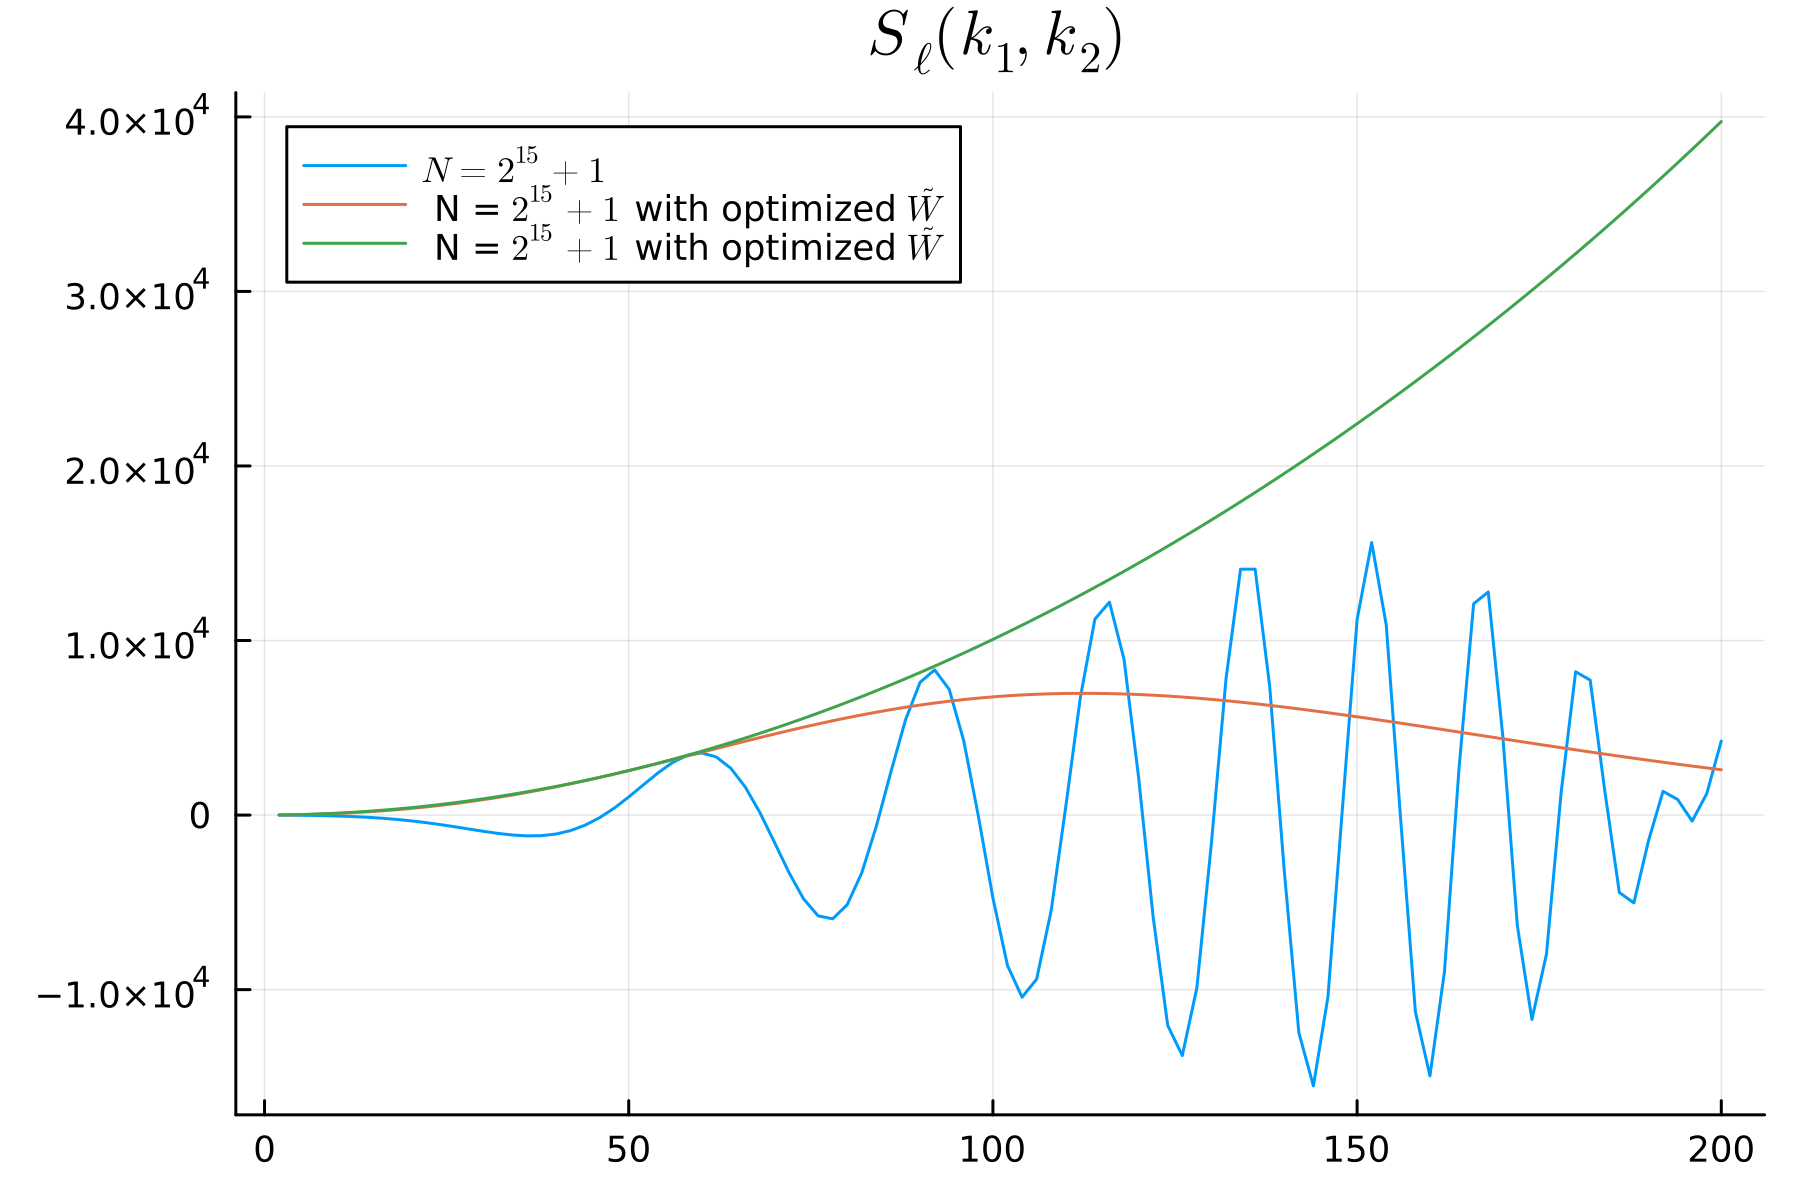

In [7]:
Slkk1 = npzread("out/runs/run_2026_06_07_033316/S_lkk.npy") # 2^15+1 with code #1
Slkk2 = npzread("out/runs/run_2026_06_09_153751/S_lkk.npy") # 2^15+1 with optimized W_tilde - code #2
Slkk3 = npzread("out/runs/run_2026_06_09_162124/S_lkk.npy") # 2^15+1 with optimized W_tilde - code #1

i = 1; j = 1;
Plots.plot(ℓ, Slkk1[i,j,:] .* ℓ .* (ℓ .+ 1) / maximum(Slkk1[i,j,:]), label = L" N = 2^{15} + 1")
Plots.plot!(ℓ, Slkk2[i,j,:] .* ℓ .* (ℓ .+ 1) / maximum(Slkk2[i,j,:]), label = L" N = $2^{15} + 1$ with optimized $\tilde W$")
Plots.plot!(ℓ, Slkk3[i,j,:] .* ℓ .* (ℓ .+ 1) / maximum(Slkk3[i,j,:]), label = L" N = $2^{15} + 1$ with optimized $\tilde W$")
Plots.plot!(dpi = 300, legend=true, title = L"S_{\ell}(k_1,k_2)")

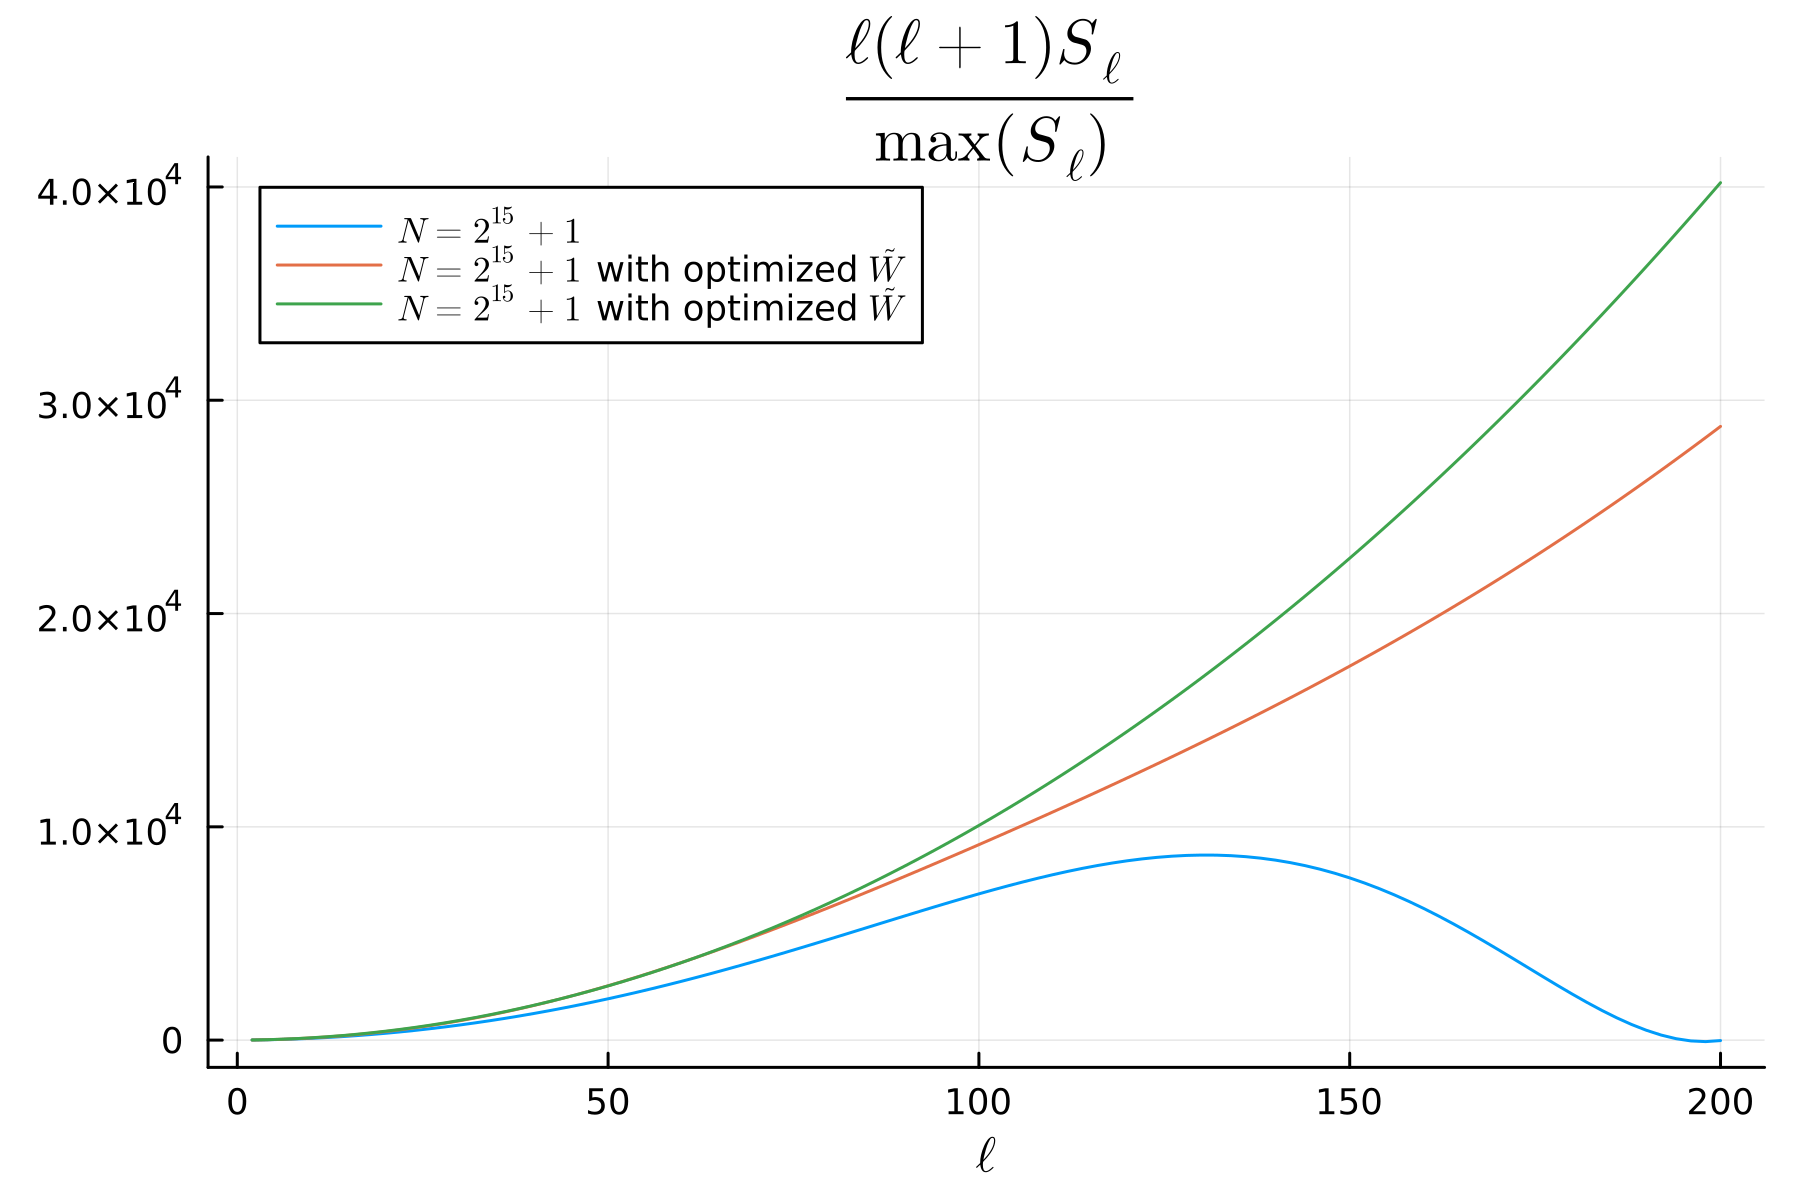

In [8]:
S1 = npzread("out/runs/run_2026_06_07_033316/S_l.npy") # 2^15+1
S2 = npzread("out/runs/run_2026_06_09_153751/S_l.npy") # 2^15+1 with optimized W_tilde
S3 = npzread("out/runs/run_2026_06_09_162124/S_l.npy") # 2^15+1 with optimized W_tilde - code #1
ℓ = LinRange(2, 200, 100)

Plots.plot(ℓ, S1 .* ℓ .* (ℓ .+ 1) / maximum(S1), label = L"$N = 2^{15} + 1$")
Plots.plot!(ℓ, S2 .* ℓ .* (ℓ .+ 1) / maximum(S2), label = L"$N = 2^{15} + 1$ with optimized $\tilde W$")
Plots.plot!(ℓ, S3 .* ℓ .* (ℓ .+ 1) / maximum(S3), label = L"$N = 2^{15} + 1$ with optimized $\tilde W$")
Plots.plot!(xlabel = L"\ell", title = L"$\frac{\ell (\ell + 1) S_\ell}{\max(S_\ell)}$", dpi = 300, legend=true)

In [ ]:
# fig = Figure(size = (800, 600))
# ax_bottom = Axis(fig[1, 1],
#     xlabel = L"\ell",
#     ylabel = L"S_\ell",
#     xgridvisible = true,
#     ygridvisible = true
# )
# ax_top = Axis(fig[1, 1],
#     xlabel = L"k \, [h/\mathrm{Mpc}]",
#     xaxisposition = :top
# )
# linkaxes!(ax_bottom, ax_top)
# hideydecorations!(ax_top, ticks = false, grid = false)
# y_data = S12 .* ℓ .* (ℓ .+ 1)
# line_bottom = lines!(ax_bottom, ℓ, y_data, 
#     label = L"N = 2^{15} + 1", 
#     color = :blue
# )
# lines!(ax_top, k_plot, y_data, 
#     color = colors[1]
# )
# Makie.xlims!(ax_bottom, minimum(ℓ), maximum(ℓ))
# Makie.xlims!(ax_top, minimum(k_plot), maximum(k_plot))
# axislegend(ax_bottom, position = :rt) # :rt sta per "right-top" (alto a destra)
# fig

In [ ]:
Plots.plot(ℓ, S1 ./ maximum(S1), label = L"$N = 2^{15} + 1$")
Plots.plot!(ℓ, S2 ./ maximum(S2), label = L"$N = 2^{15} + 1$ with optimized $\tilde W$")
# Plots.plot!(    twiny(),
#     k_plot,
#     S12,
#     label = false,
#     color = colors[1],
#     xlabel = L"k \, [h/\mathrm{Mpc}]",
#     ylabel = L"S_\ell "
# )
Plots.plot!(dpi = 300, legend=true)